# CIFAR-10 Image Classification using Convolutional Neural Network (CNN)

## Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) model that can classify images into one of the ten categories of the CIFAR-10 dataset. This project demonstrates image preprocessing, CNN model building, training, evaluation, and prediction using TensorFlow and Keras.

In [3]:
import tarfile

# Extract the uploaded dataset
with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall()

print("Dataset extracted successfully!")

/tmp/ipykernel_1043/2136455671.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset extracted successfully!


In [4]:
import os

print(os.listdir())

['.config', 'cifar-10-python.tar.gz', 'cifar-10-batches-py', 'sample_data']


In [5]:
import pickle
import numpy as np

def load_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    return batch

# Load training data
train_images = []
train_labels = []

for i in range(1, 6):
    batch = load_batch(f'cifar-10-batches-py/data_batch_{i}')
    train_images.append(batch[b'data'])
    train_labels.extend(batch[b'labels'])

train_images = np.concatenate(train_images)
train_images = train_images.reshape((50000, 3, 32, 32)).transpose(0, 2, 3, 1)

# Load test data
test_batch = load_batch('cifar-10-batches-py/test_batch')
test_images = test_batch[b'data']
test_labels = np.array(test_batch[b'labels'])

test_images = test_images.reshape((10000, 3, 32, 32)).transpose(0, 2, 3, 1)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print("Training Images:", train_images.shape)
print("Training Labels:", train_labels.shape)
print("Testing Images:", test_images.shape)
print("Testing Labels:", test_labels.shape)

Training Images: (50000, 32, 32, 3)
Training Labels: (50000,)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000,)


In [6]:
# Normalize pixel values (0 to 255 -> 0 to 1)

train_images = train_images / 255.0
test_images = test_images / 255.0

print("Normalization completed!")

Normalization completed!


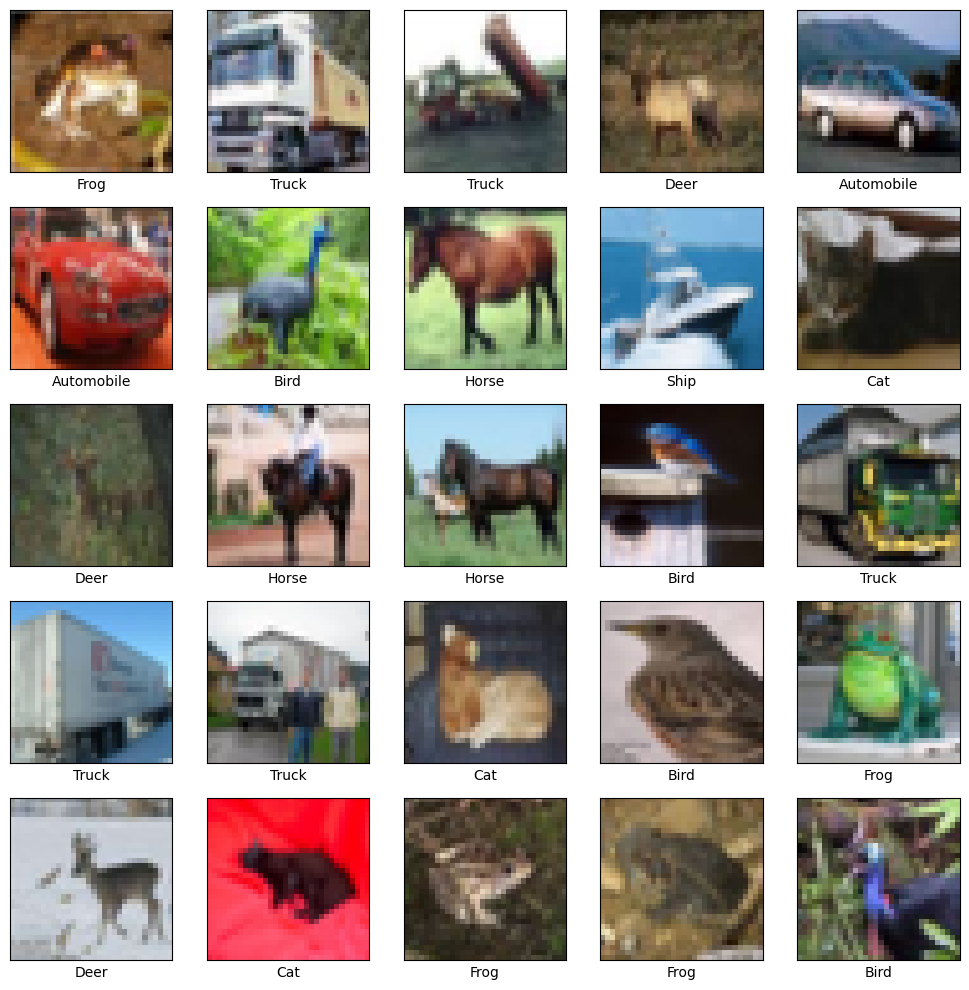

In [7]:
import matplotlib.pyplot as plt

class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i]])

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4402 - loss: 1.5291 - val_accuracy: 0.5533 - val_loss: 1.2407
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5896 - loss: 1.1563 - val_accuracy: 0.6283 - val_loss: 1.0621
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6538 - loss: 0.9883 - val_accuracy: 0.6600 - val_loss: 0.9748
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6914 - loss: 0.8844 - val_accuracy: 0.6704 - val_loss: 0.9267
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7185 - loss: 0.8095 - val_accuracy: 0.6980 - val_loss: 0.8740
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7370 - loss: 0.7518 - val_accuracy: 0.7004 - val_loss: 0.8594
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7544 - loss: 0.7014 - val_accuracy: 0.7091 - val_loss: 0.8402
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7698 - loss: 0.6525 

In [11]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7102 - loss: 0.8921
Test Accuracy: 0.7102000117301941
Test Loss: 0.892099916934967


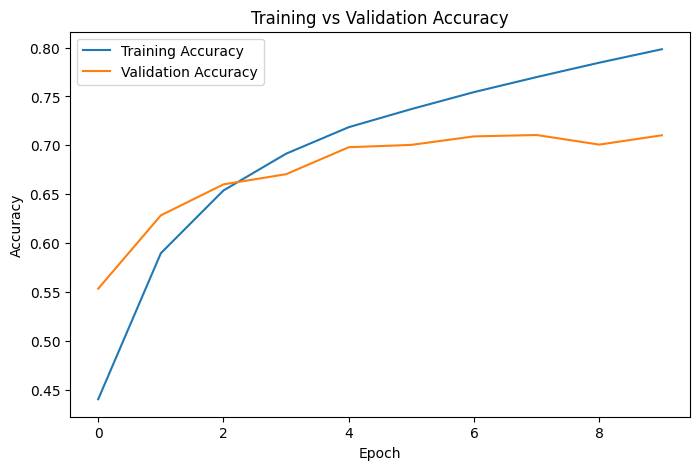

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


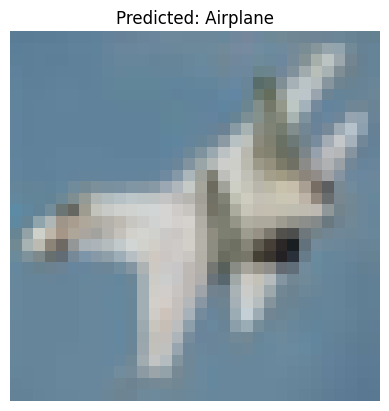

Actual Label: Airplane
Predicted Label: Airplane


In [13]:
predictions = model.predict(test_images)

index = 10

plt.imshow(test_images[index])
plt.title("Predicted: " + class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

print("Actual Label:", class_names[test_labels[index]])
print("Predicted Label:", class_names[np.argmax(predictions[index])])

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify images from the CIFAR-10 dataset into ten different categories. The dataset was preprocessed by normalizing pixel values, and the CNN model was trained using TensorFlow and Keras. After training, the model was evaluated on the test dataset and achieved good classification accuracy. The results demonstrate that CNNs are highly effective for image classification tasks because they automatically learn important features from images. This project provides practical knowledge of deep learning, computer vision, and image recognition using Python.